# Multiple Lr with more than 1 independent features. :

## Here we're using "datasets/economic_index.csv" where:
- We have 2 independent features and one dependent features with Linear relation .
- Thus, it's Multi-LR.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm


In [2]:
df=pd.read_csv("../datasets/economic_index.csv")
df.head()


,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [11]:

print(df.isnull().sum())
print("---------------------------------- ")

print(df.info())

Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64
---------------------------------- 
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         24 non-null     int64  
 1   year               24 non-null     int64  
 2   month              24 non-null     int64  
 3   interest_rate      24 non-null     float64
 4   unemployment_rate  24 non-null     float64
 5   index_price        24 non-null     int64  
dtypes: float64(2), int64(4)
memory usage: 1.3 KB
None


In [23]:
print(df.columns.tolist())

['interest_rate', 'unemployment_rate', 'index_price']


In [24]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


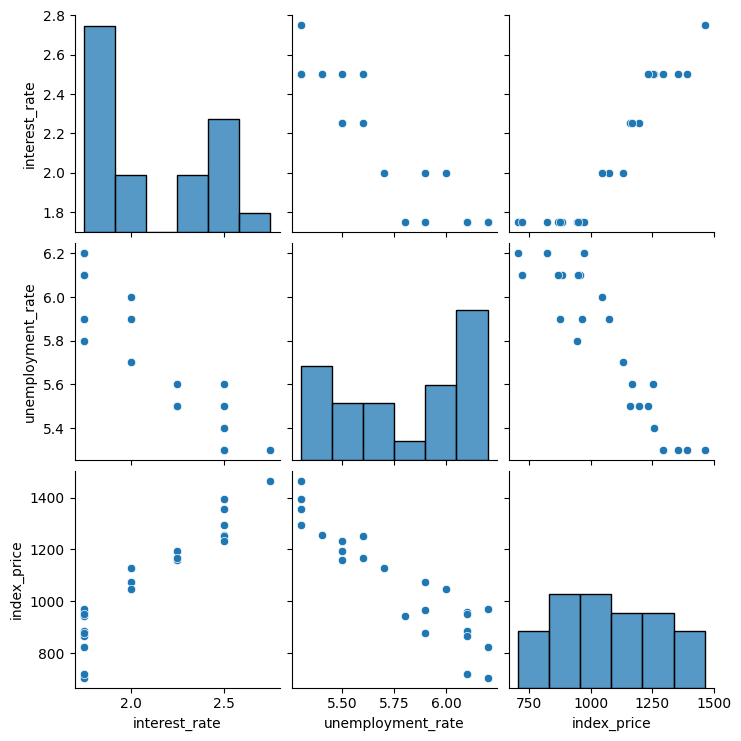

In [25]:
sns.pairplot(df)

In [26]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'berozgari')

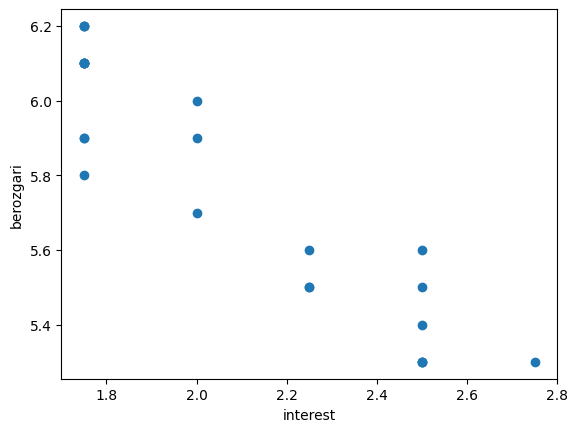

In [ ]:

print(plt.scatter(df["interest_rate"], df["unemployment_rate"]))
plt.xlabel("interest")
plt.ylabel("berozgari")


In [ ]:
# Printing the Dependent and independent vars.
X = df[['interest_rate', 'unemployment_rate']] # Note the double brackets for 2D array
y = df['index_price']


,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [36]:
# train test split :
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [ ]:
# Standardization :
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.fit_transform(X_test)


array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

Axes(0.125,0.11;0.775x0.77)


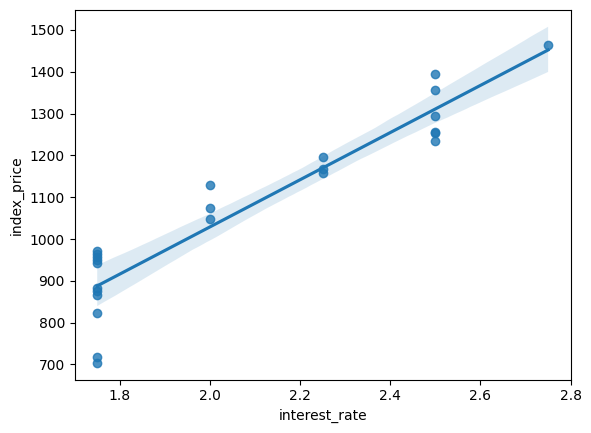

In [43]:
import seaborn as sns

# Fix: Use keyword arguments
print(sns.regplot(x=df["interest_rate"], y=df["index_price"]))



Axes(0.125,0.11;0.775x0.77)


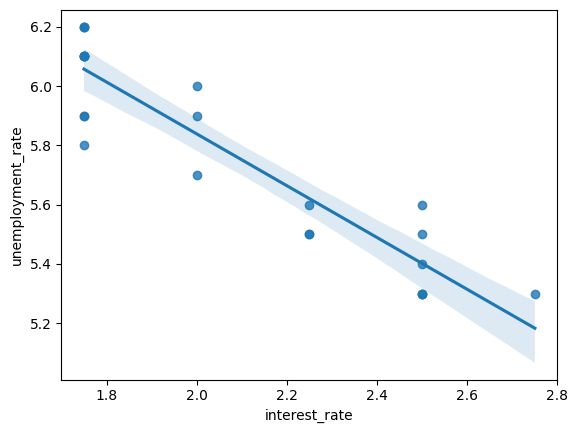

In [45]:
print(sns.regplot(x=df["interest_rate"], y=df["unemployment_rate"]))

In [49]:
from sklearn.linear_model import LinearRegression
regression =LinearRegression()
regression.fit(X_train_scaled, y_train)

print("Coeff:", regression.coef_)
print("Intercept:", regression.intercept_)

Coeff: [  88.27275507 -116.25716066]
Intercept: 1053.4444444444443


# Doing the cross validation of the data for hypertuning of model.

In [ ]:
#Cross validation 
from sklearn.model_selection import cross_val_score
validn_score= cross_val_score(regression, X_train, y_train, scoring="neg_mean_squared_error",cv=3)


### Meaning of the syntax :
- Suppose we have the data of 100 vals of which we use 900 in trian and 100 in test.
- Now using the cross validatoin we can hypertune our model by again splitting the trainig data into training and validation.
- Suppose if we have cv=5 this means we split 900/5 =180
- So, we divide the data into chunks of 180 datasets.
- In the end we take the avg. of all the CVs
- And for good model working the -ve MSE should be close to 0. 

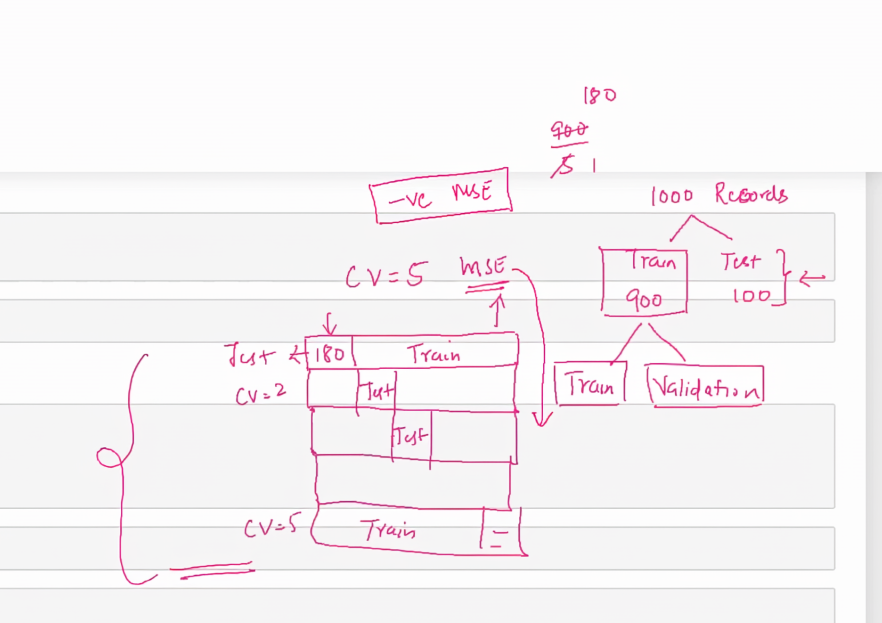